In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from nflows.transforms.normalization import ActNorm
from deepinv.optim.data_fidelity import L2
from deepinv.models import BM3D
from deepinv.physics import Inpainting
from deepinv.optim.prior import PnP
from deepinv.optim.optimizers import optim_builder
from tqdm import tqdm

from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.inverse_problems.riemannian_ambient_flow import RiemannianAmbientFlowProblem
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean
from src.riemannian_autoencoder.image.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackImageRiemannianAutoencoder
from src.riemannian_autoencoder.image.pullback.standard import StandardPullbackImageRiemannianAutoencoder
from src.transforms.multi_layer_parity_conv2d.tanh import MultiLayerTanhParityConv2DTransform
from src.transforms.parity_conv import ParityConv2DTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

# Experiment settings
results_folder = os.path.join("results", "mnist_ones", "pnp_raf")

/Users/wdiepeveen/Documents/Postdoc/projects/4 - score-based Riemannian geometry from corrupted data/src/Score-based-Riemannian-geometry-from-corrupted-data/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load MNIST dataset
size = 28
H, W = size, size
mnist_mean = 0.1307
mnist_var = 0.3081

# define the transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    # torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

# load the full MNIST dataset
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# calculate the split point (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# create train and validation subsets
clean_data_train_, clean_data_val_ = random_split(full_dataset, [train_size, val_size])

# reformat data to be tensors instead of lists
clean_data_train = torch.stack([data[0] for data in clean_data_train_])
clean_data_val = torch.stack([data[0] for data in clean_data_val_])

### Denoising ###

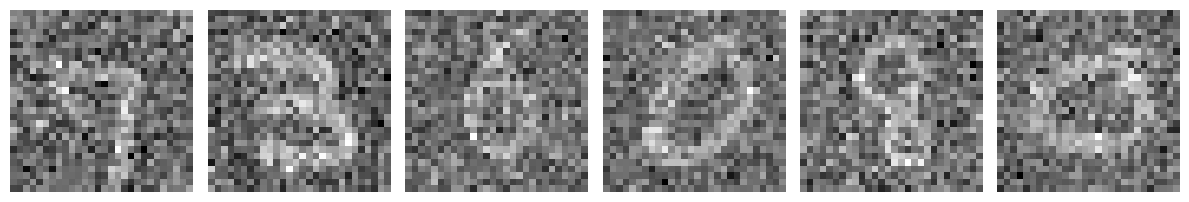

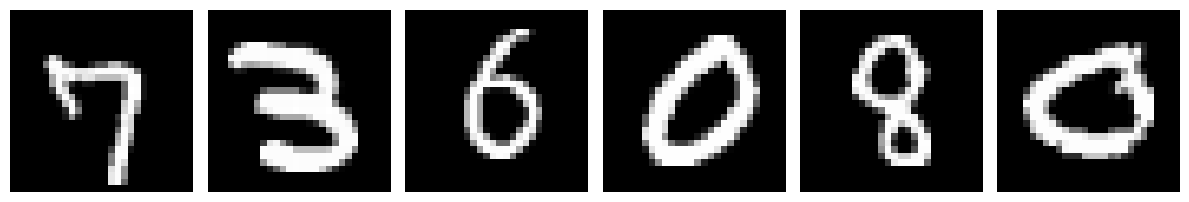

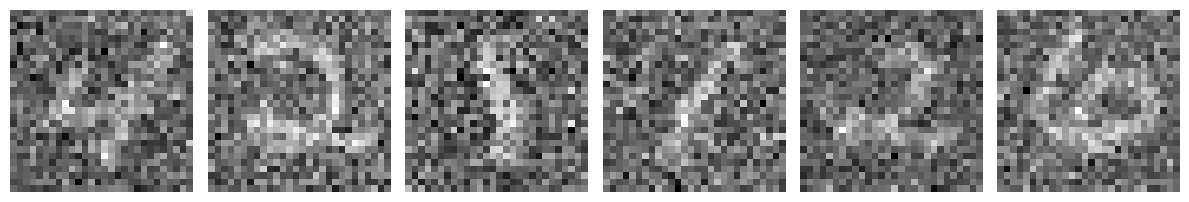

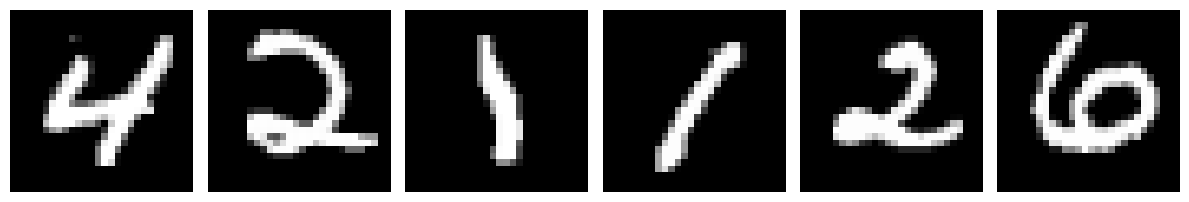

In [3]:
# construct noisy corrupted dataset
corruption_level = 0.5
data_train = clean_data_train + corruption_level * torch.randn_like(clean_data_train) 
data_val = clean_data_val + corruption_level * torch.randn_like(clean_data_val) 

# create the DataLoaders
batch_size = 10
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(data_val, batch_size=batch_size, shuffle=False)

clean_train_loader = DataLoader(clean_data_train, batch_size=batch_size, shuffle=False) # for checking later
clean_val_loader = DataLoader(clean_data_val, batch_size=batch_size, shuffle=False) # for checking later

# get a batch of examples from the training set
train_examples = next(iter(train_loader))
val_examples = next(iter(val_loader))
clean_train_examples = next(iter(clean_train_loader))
clean_val_examples = next(iter(clean_val_loader))

# plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_examples[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(clean_train_examples[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_examples[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(clean_val_examples[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

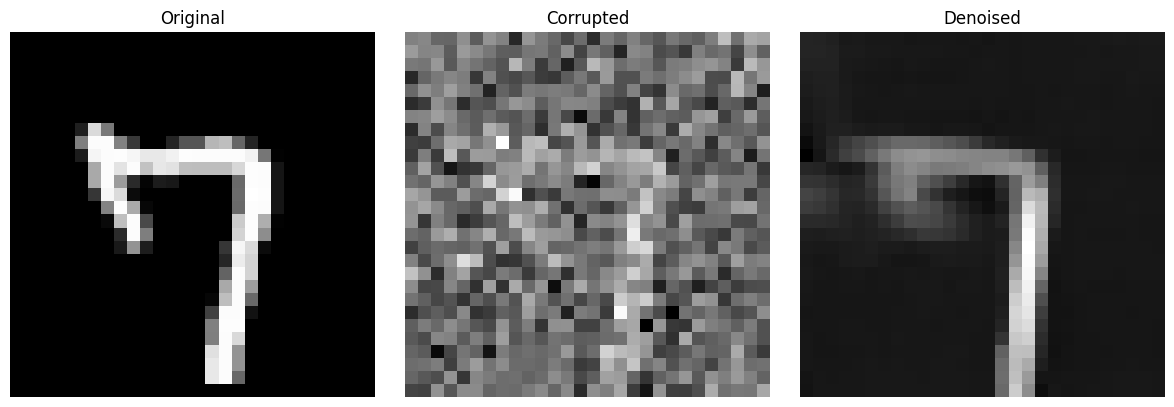

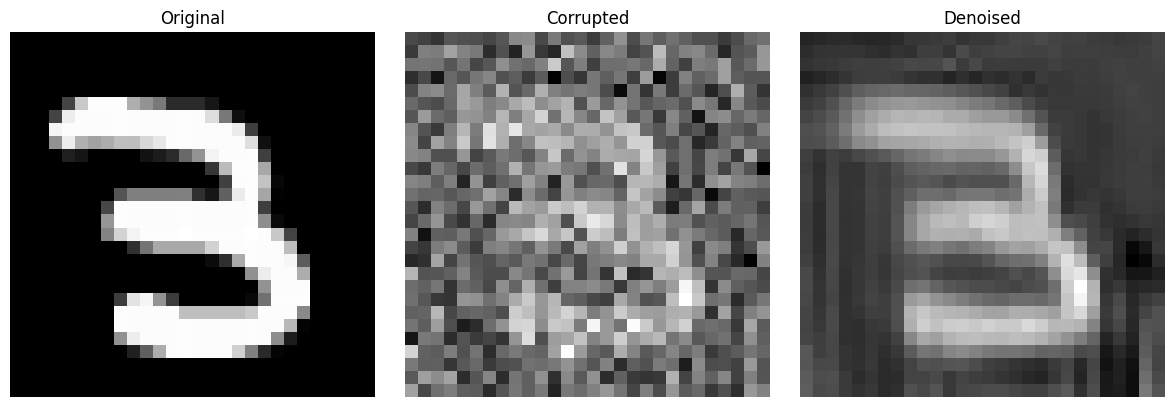

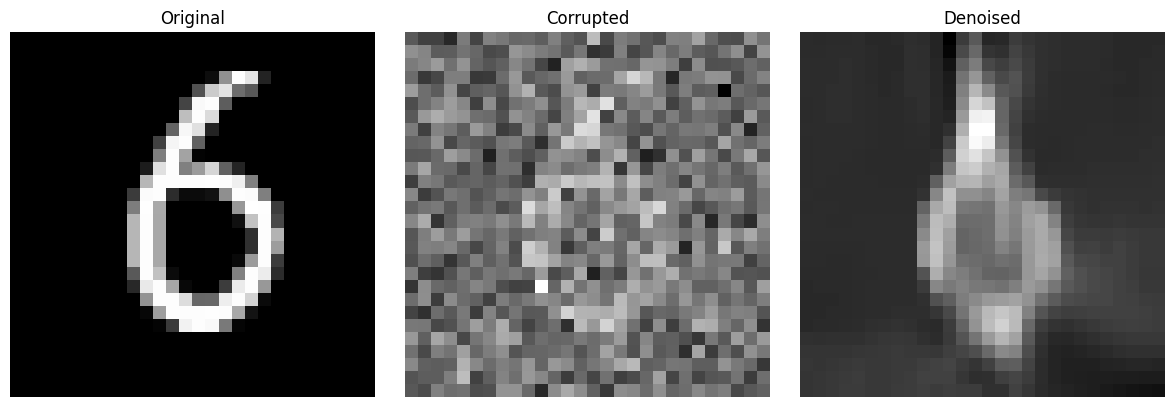

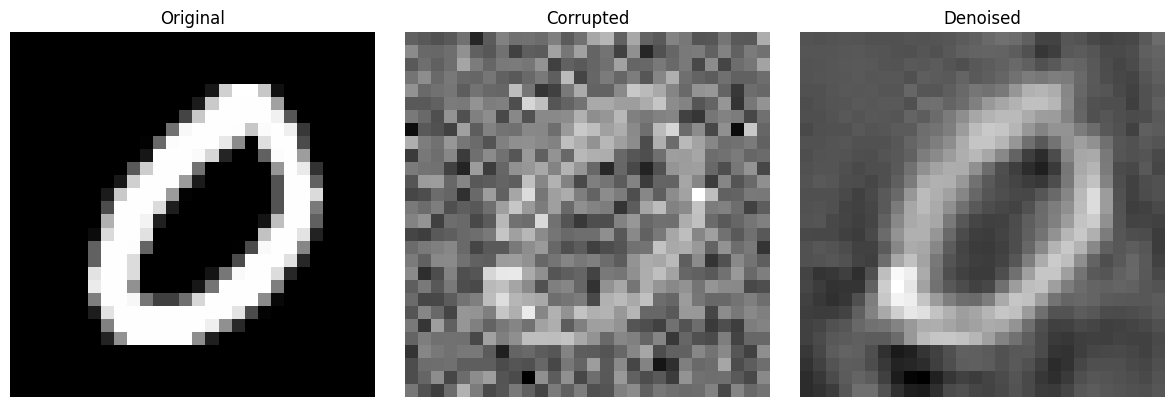

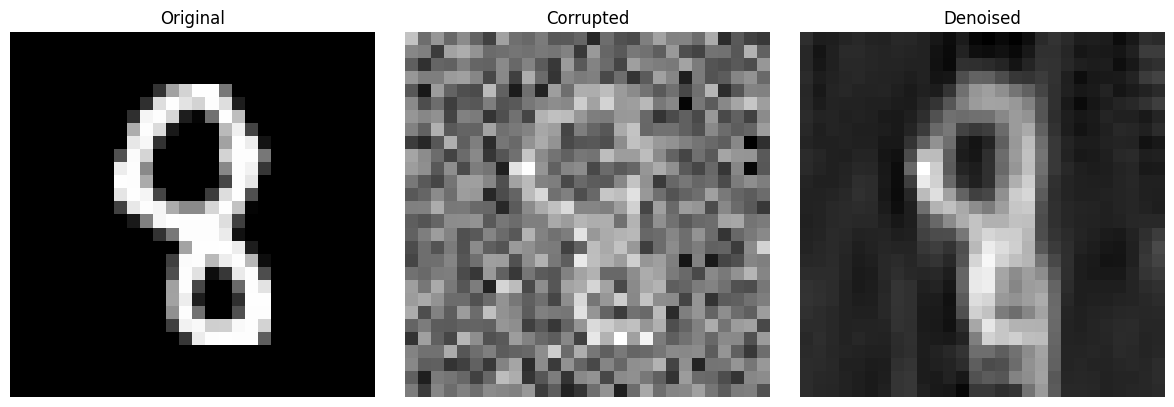

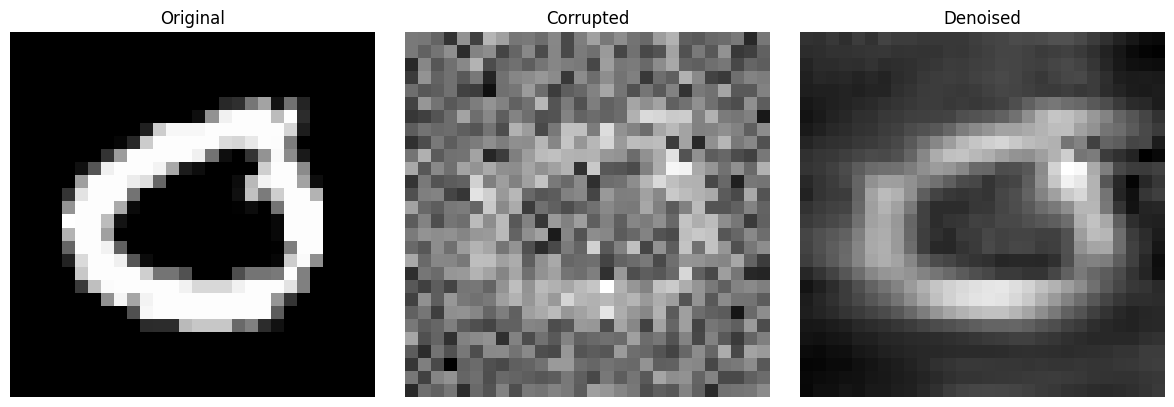

In [4]:
# use PnP to reconstruct images
denoiser = BM3D()
denoiser.eval()

# Denoising function for minibatch
def denoise_batch(batch, denoiser):
    with torch.no_grad():
        batch = batch.to(device)
        out = denoiser(batch, corruption_level)
    return out.cpu()

# Get a batch from your noisy MNIST loader (replace this with your batch)
# For demonstration, use: noisy_batch, clean_batch = next(iter(trainloader)), next(iter(cleantrainloader))
noisy_batch, clean_batch = next(iter(train_loader)), next(iter(clean_train_loader))

# Denoise the batch
denoised_batch = denoise_batch(noisy_batch, denoiser)

# Plot original, noisy, and denoised images
def show_images(img_list, titles):
    fig, axes = plt.subplots(1, len(img_list), figsize=(12, 4))
    for i, (img, title) in enumerate(zip(img_list, titles)):
        axes[i].imshow(img[0].cpu().numpy().squeeze(), cmap="gray")
        axes[i].set_title(title)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

# Show first six images of each
for i in range(6):
    show_images(
        [clean_batch[i], noisy_batch[i], denoised_batch[i]],
        ["Original", "Corrupted", "Denoised"]
    )

### Inpainting ###

In [5]:
# construct noisy corrupted dataset
img_shape = (1, H, W)    # For MNIST
mask_ratio = 0.7         # 70% observed pixels

# create an inpainting operator with a random mask (Bernoulli)
physics = Inpainting(tensor_size=img_shape, mask=mask_ratio)
noise_level = 0.2

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_9234/1411262858.py:6: DeprecationWarning: Argument 'tensor_size' is deprecated and will be removed in a future version. Use 'img_size' instead.
  physics = Inpainting(tensor_size=img_shape, mask=mask_ratio)


In [6]:
# set up PnP solver
params_algo = {"stepsize": 0.99, "g_param": 0.2, "sigma": 0.99}
max_iter = 20
early_stop = True  # stop the algorithm when convergence is reached

# Select the data fidelity term
data_fidelity = L2()

# Specify the denoising prior
denoiser = BM3D()
prior = PnP(denoiser=denoiser)

# instantiate the algorithm class to solve the IP problem.
model = optim_builder(
    iteration="PGD",
    prior=prior,
    data_fidelity=data_fidelity,
    early_stop=early_stop,
    max_iter=max_iter,
    verbose=True,
    params_algo=params_algo,
)

In [ ]:
# test run 
x_gt = clean_batch[0]  # ground truth
x_noisy = x_gt + noise_level * torch.randn_like(x_gt)
y = physics(x_noisy)  # observed pixels

# Set up the initial guess (often zeros or observed values):
x_init = torch.zeros_like(x_gt)

# Run PnP to reconstruct
x_rec = model(y, physics)

# Show original, mask, corrupted, and reconstructed images
show_images(
        [x_gt, physics.mask, y, x_rec],
        ["Original", "Mask", "Corrupted", "Reconstructed"]
    )

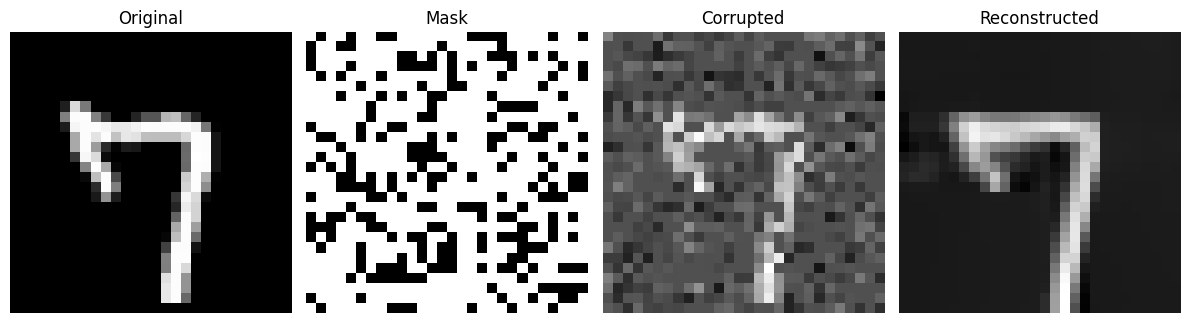

In [ ]:
# construct the whole reconstructed data set for all corrupted images